***I have created a synthetic data where we have 920 samples randomly generated with 20 extreme outliers in the data***    
***Features have higly different Scale***

In [24]:
# Import the modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler , RobustScaler
from sklearn.metrics import accuracy_score, classification_report

In [25]:
# Import the data
df = pd.read_csv('synthetic_data.csv')

print(df.head())

   Feature1      Feature2  Class  is_outlier
0  0.063460  45499.681917      0       False
1  0.272205  11427.645996      0       False
2  0.083721  -6622.043301      0       False
3  0.160549  22046.832299      0       False
4  0.051812  66488.831046      0       False


In [26]:
df['is_outlier'].value_counts() # We have 20 extreme outliers as we can see

is_outlier
False    1500
True       30
Name: count, dtype: int64

In [27]:
df.describe()

,Feature1,Feature2,Class
count,1530.000000,1530.000000,1530.000000
mean,0.496942,50660.644695,0.997386
std,0.320952,34022.793316,0.815156
min,-0.743631,-95845.862155,0.000000
25%,0.219072,25455.559851,0.000000
50%,0.504823,49367.411354,1.000000
75%,0.769187,75503.623780,2.000000
max,1.585965,237609.613106,2.000000


In [28]:
X = df.iloc[:,:2]
y = df['Class']

In [29]:
print(f"Shape X -> {X.shape}")
print(f"Shape y -> {y.shape}")

Shape X -> (1530, 2)
Shape y -> (1530,)


<Axes: xlabel='Feature1', ylabel='Feature2'>

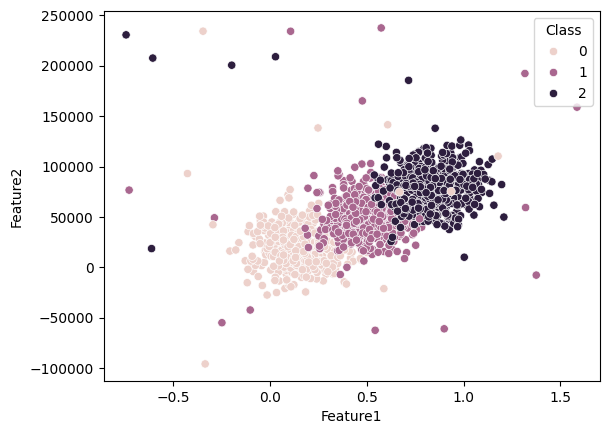

In [37]:
# Plot the Features
sns.scatterplot(x = df['Feature1'] , y=df['Feature2'] , hue=df['Class'])


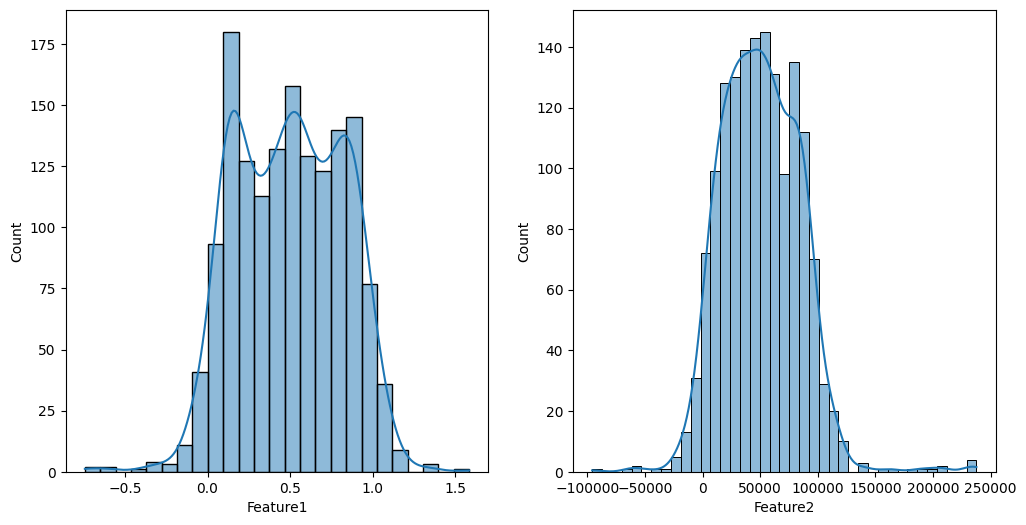

In [31]:
# (i) Histogram + Kdeplot
fig , ax = plt.subplots(ncols=2 , figsize=(12,6))
sns.histplot(df['Feature1'] , ax = ax[0] , kde=True)
sns.histplot(df['Feature2'] , ax=ax[1] , kde=True)
plt.show()

- We clearly see the seperation b/w the classes 
- There were some outliers but we did not plot them so that we can see our major data clearly

In [32]:
# Let us split the data now
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.3 , random_state = 42)

In [33]:
# Let us first Normalize our data using MinMaxScaling
from sklearn.preprocessing import MinMaxScaler, RobustScaler
min_max_scale  =MinMaxScaler()
robust_scale = RobustScaler()

# Scaling the Features with MinMax Scaler
X_train_mm_scaled = pd.DataFrame(min_max_scale.fit_transform(X_train) , columns = X_train.columns)
X_test_mm_scaled = pd.DataFrame(min_max_scale.transform(X_test) , columns = X_test.columns)

# Scaling the Features with Robust Scaler
X_train_rc_scaled = pd.DataFrame(robust_scale.fit_transform(X_train) , columns = X_train.columns)
X_test_rc_scaled = pd.DataFrame(robust_scale.transform(X_test) , columns = X_test.columns)

In [34]:
# Let us now fit the Logistic Regression Model and check the Evalutaion
from sklearn.linear_model import LogisticRegression


lr = LogisticRegression(C = 0.01 , max_iter=1000) # Creating model object
model = lr.fit(X_train , y_train) # Fitting the model on unscaled data
y_pred = model.predict(X_test) # predicting the Test Output without scaling



lr_mm_scaled = LogisticRegression(C = 0.01 ,max_iter=1000)
model_mm_scaled = lr.fit(X_train_mm_scaled , y_train) # Fitting the model on MinMax Scaled  data
y_pred_mm_scaled = model_mm_scaled.predict(X_test_mm_scaled) # predicting the Test Output After MinMax Scaling scaling



lr_rc_scaled = LogisticRegression(C = 0.01 ,max_iter=1000)
model_rc_scaled = lr.fit(X_train_rc_scaled , y_train) # Fitting the model on Robust Scaled  data
y_pred_rc_scaled = model_rc_scaled.predict(X_test_rc_scaled) # predicting the Test Output After Robust Scaling scaling




In [35]:
# ----------- Evaluation And Comparison ------------------

from sklearn.metrics import accuracy_score , classification_report
print(f"\tWithout Scaling Accuracy Score->\n{accuracy_score(y_test , y_pred)}\n")
print(f"\tMinMax Scaling Accuracy Score->\n{accuracy_score(y_test , y_pred_mm_scaled)}\n")
print(f"\tRobust Scaling Accuracy Score->\n{accuracy_score(y_test , y_pred_rc_scaled)}\n")

	Without Scaling Accuracy Score->
0.7211328976034859

	MinMax Scaling Accuracy Score->
0.8191721132897604

	Robust Scaling Accuracy Score->
0.8823529411764706



In [36]:
print(f"\tWithout Scaling Classification Report->\n{classification_report(y_test , y_pred)}\n")
print(f"\tMinMax Scaling Classification Report->\n{classification_report(y_test , y_pred_mm_scaled)}\n")
print(f"\tRobust Scaling Classification Report->\n{classification_report(y_test , y_pred_rc_scaled)}\n")

	Without Scaling Classification Report->
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       150
           1       0.56      0.62      0.59       144
           2       0.78      0.75      0.77       165

    accuracy                           0.72       459
   macro avg       0.72      0.72      0.72       459
weighted avg       0.73      0.72      0.72       459


	MinMax Scaling Classification Report->
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       150
           1       0.68      0.84      0.75       144
           2       0.96      0.65      0.78       165

    accuracy                           0.82       459
   macro avg       0.84      0.83      0.82       459
weighted avg       0.84      0.82      0.82       459


	Robust Scaling Classification Report->
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       150
      